In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
goog = pd.read_csv("../data/raw/GOOG.csv")
goog.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/GOOG.csv'

In [4]:
goog = pd.read_csv("data/raw/GOOG.csv")
goog.head()


,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


In [5]:
goog["Date"] = pd.to_datetime(goog["Date"])
goog.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3774 non-null   datetime64[us]
 1   Close   3774 non-null   float64       
 2   High    3774 non-null   float64       
 3   Low     3774 non-null   float64       
 4   Open    3774 non-null   float64       
 5   Volume  3774 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 177.0 KB


In [6]:
goog["Daily_Return"] = goog["Close"].pct_change()
goog[["Date", "Close", "Daily_Return"]].head()

,Date,Close,Daily_Return
0,2009-01-02,7.948608,NaN
1,2009-01-05,8.115089,0.020945
2,2009-01-06,8.263762,0.018321
3,2009-01-07,7.965677,-0.036071
4,2009-01-08,8.044340,0.009875


In [7]:
goog["SMA_20"] = goog["Close"].rolling(window=20).mean()
goog["SMA_50"] = goog["Close"].rolling(window=50).mean()

goog[["Date", "Close", "SMA_20", "SMA_50"]].tail()

,Date,Close,SMA_20,SMA_50
3769,2023-12-22,141.750000,135.009596,133.914786
3770,2023-12-26,141.849304,135.246477,133.999010
3771,2023-12-27,140.478683,135.386520,134.017881
3772,2023-12-28,140.319748,135.628861,134.023641
3773,2023-12-29,139.972137,135.976979,134.056417


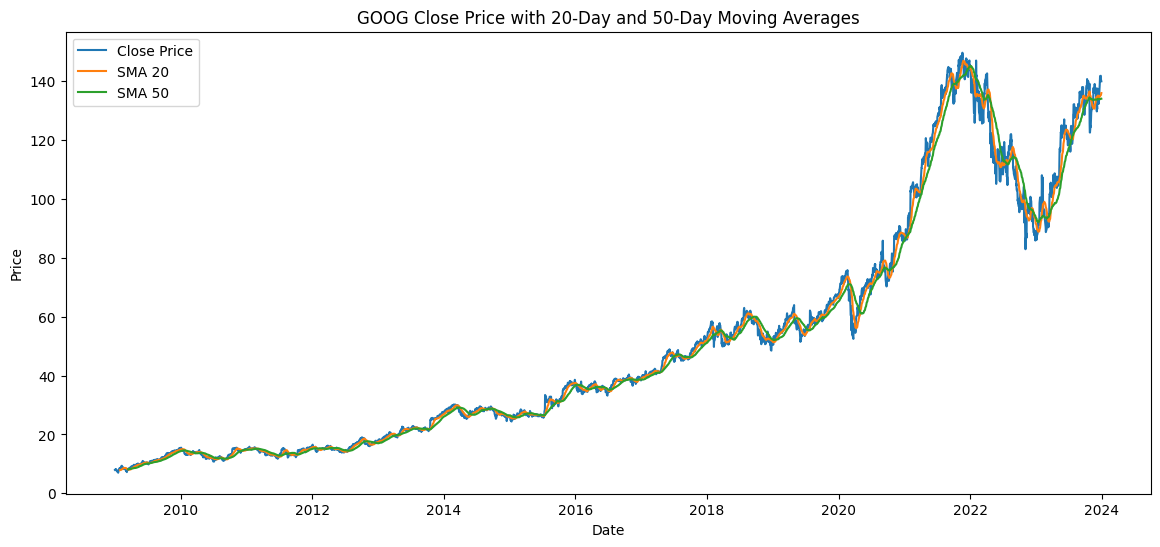

In [8]:
plt.figure(figsize=(14, 6))

plt.plot(goog["Date"], goog["Close"], label="Close Price")
plt.plot(goog["Date"], goog["SMA_20"], label="SMA 20")
plt.plot(goog["Date"], goog["SMA_50"], label="SMA 50")

plt.title("GOOG Close Price with 20-Day and 50-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [9]:
# Calculate price changes
delta = goog["Close"].diff()

# Separate gains and losses
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

# Calculate 14-day average gain and loss
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

# Calculate Relative Strength and RSI
rs = avg_gain / avg_loss
goog["RSI_14"] = 100 - (100 / (1 + rs))

# Display results
goog[["Date", "Close", "RSI_14"]].tail()

,Date,Close,RSI_14
3769,2023-12-22,141.750000,74.016699
3770,2023-12-26,141.849304,72.182037
3771,2023-12-27,140.478683,70.915160
3772,2023-12-28,140.319748,58.289315
3773,2023-12-29,139.972137,63.741198


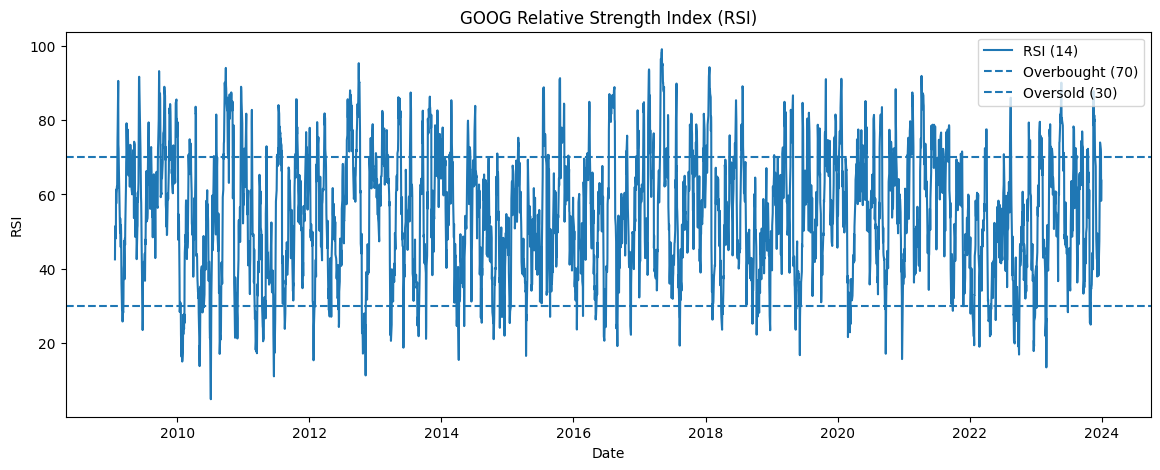

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(goog["Date"], goog["RSI_14"], label="RSI (14)")
plt.axhline(70, linestyle="--", label="Overbought (70)")
plt.axhline(30, linestyle="--", label="Oversold (30)")

plt.title("GOOG Relative Strength Index (RSI)")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.show()